# 시퀀스 의존성 분석
### 핵심 질문: 이 데이터에 장기 의존성이 존재하는가?
- Lag별 상관계수 감쇠 분석
- 피처 중요도 시각화
- 에피소드 길이와 예측 오차의 관계

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import os
os.makedirs('figures', exist_ok=True)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

## 1. 데이터 로드

In [2]:
data_dir = Path('../data/raw')
train = pd.read_csv(data_dir / 'train.csv')
train['result_name'] = train['result_name'].fillna('None')
print(f'Train rows: {len(train)}')
print(f'Columns: {list(train.columns)}')

Train rows: 356721
Columns: ['game_id', 'period_id', 'episode_id', 'time_seconds', 'team_id', 'player_id', 'action_id', 'type_name', 'result_name', 'start_x', 'start_y', 'end_x', 'end_y', 'is_home', 'game_episode']


## 2. Lag별 상관계수 분석
### 가설: 직전 이벤트(lag-1)가 핵심이고, 과거로 갈수록 상관관계가 급격히 감소한다

In [3]:
# 에피소드별로 lag-k 이벤트의 dx/dy와 타겟 dx/dy의 상관관계 계산
records = []

for ep, group in train.groupby('game_episode'):
    group = group.sort_values('action_id').reset_index(drop=True)
    n = len(group)
    last = group.iloc[-1]

    if pd.isna(last['end_x']) or pd.isna(last['end_y']):
        continue

    target_dx = last['end_x'] - last['start_x']
    target_dy = last['end_y'] - last['start_y']

    record = {
        'game_episode': ep,
        'target_dx': target_dx,
        'target_dy': target_dy,
        'ep_length': n,
        'last_start_x': last['start_x'],
        'last_start_y': last['start_y'],
    }

    # lag-1 ~ lag-5: 타겟 이벤트로부터 k번째 이전 이벤트
    for lag in range(1, 6):
        if n >= lag + 1:
            prev = group.iloc[-(lag + 1)]
            if pd.notna(prev['end_x']) and pd.notna(prev['end_y']):
                record[f'lag{lag}_dx'] = prev['end_x'] - prev['start_x']
                record[f'lag{lag}_dy'] = prev['end_y'] - prev['start_y']
                record[f'lag{lag}_type'] = prev['type_name']
            else:
                record[f'lag{lag}_dx'] = np.nan
                record[f'lag{lag}_dy'] = np.nan
                record[f'lag{lag}_type'] = 'None'
        else:
            record[f'lag{lag}_dx'] = np.nan
            record[f'lag{lag}_dy'] = np.nan
            record[f'lag{lag}_type'] = 'None'

    records.append(record)

df = pd.DataFrame(records)
print(f'총 에피소드: {len(df)}')
print(f'에피소드 길이 분포:')
print(df['ep_length'].describe())

총 에피소드: 15435
에피소드 길이 분포:
count    15435.000000
mean        23.111176
std         21.990855
min          1.000000
25%          8.000000
50%         16.000000
75%         31.000000
max        270.000000
Name: ep_length, dtype: float64


In [4]:
# Lag별 상관계수 계산
lag_corr_dx = []
lag_corr_dy = []
lag_n = []

for lag in range(1, 6):
    col_dx = f'lag{lag}_dx'
    col_dy = f'lag{lag}_dy'
    valid = df[[col_dx, col_dy, 'target_dx', 'target_dy']].dropna()
    corr_dx = valid[col_dx].corr(valid['target_dx'])
    corr_dy = valid[col_dy].corr(valid['target_dy'])
    lag_corr_dx.append(corr_dx)
    lag_corr_dy.append(corr_dy)
    lag_n.append(len(valid))
    print(f'lag-{lag}: dx corr={corr_dx:.4f}, dy corr={corr_dy:.4f}, n={len(valid)}')

lag-1: dx corr=0.0037, dy corr=0.1465, n=15428
lag-2: dx corr=-0.1771, dy corr=-0.0149, n=14849
lag-3: dx corr=-0.0750, dy corr=-0.0477, n=14223
lag-4: dx corr=-0.0566, dy corr=-0.0744, n=13699
lag-5: dx corr=-0.0392, dy corr=-0.0463, n=13071


In [5]:
# 현재 위치와의 상관계수도 함께 비교
corr_x_dx = df['last_start_x'].corr(df['target_dx'])
corr_x_dy = df['last_start_y'].corr(df['target_dy'])
print(f'last_start_x → target_dx: {corr_x_dx:.4f}')
print(f'last_start_y → target_dy: {corr_x_dy:.4f}')

last_start_x → target_dx: -0.4094
last_start_y → target_dy: -0.1493


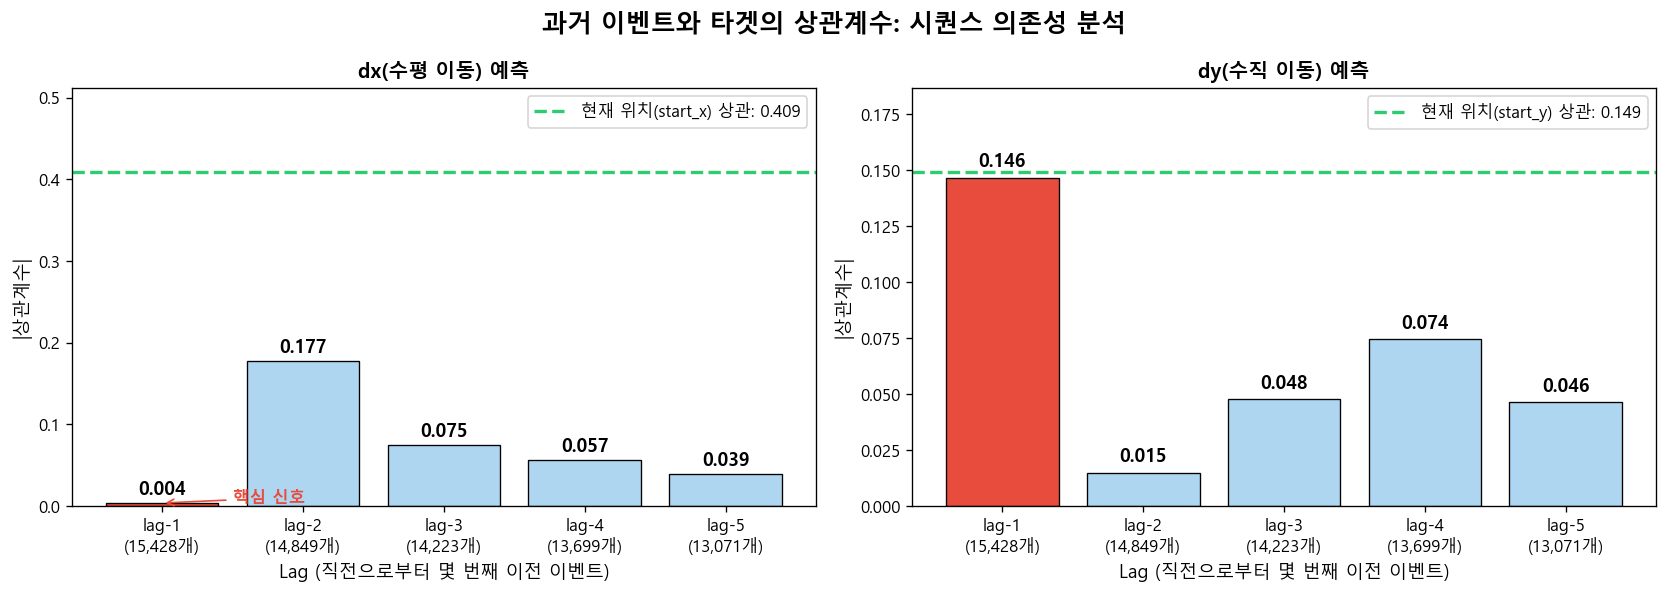


[해석]
  lag-1 → lag-2 dx 감쇠율: -4642.1%
  lag-1 → lag-5 dx 감쇠율: -949.0%


In [6]:
# ============================================================
# 핵심 시각화 1: Lag별 상관계수 감쇠
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('과거 이벤트와 타겟의 상관계수: 시퀀스 의존성 분석', fontsize=15, fontweight='bold')

lags = list(range(1, 6))
colors_dx = ['#E74C3C' if i == 0 else '#AED6F1' for i in range(5)]
colors_dy = ['#E74C3C' if i == 0 else '#AED6F1' for i in range(5)]

# dx 상관계수
ax1 = axes[0]
bars = ax1.bar(lags, [abs(c) for c in lag_corr_dx], color=colors_dx, edgecolor='black', linewidth=0.8)
ax1.axhline(abs(corr_x_dx), color='#2ECC71', linestyle='--', linewidth=2,
            label=f'현재 위치(start_x) 상관: {abs(corr_x_dx):.3f}')
for bar, val in zip(bars, lag_corr_dx):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{abs(val):.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_xlabel('Lag (직전으로부터 몇 번째 이전 이벤트)', fontsize=11)
ax1.set_ylabel('|상관계수|', fontsize=11)
ax1.set_title('dx(수평 이동) 예측', fontsize=12, fontweight='bold')
ax1.set_xticks(lags)
ax1.set_xticklabels([f'lag-{l}\n({lag_n[i-1]:,}개)' for l, i in zip(lags, lags)])
ax1.set_ylim(0, max([abs(c) for c in lag_corr_dx] + [abs(corr_x_dx)]) * 1.25)
ax1.legend(fontsize=10)
ax1.annotate('핵심 신호', xy=(1, abs(lag_corr_dx[0])), xytext=(1.5, abs(lag_corr_dx[0])*1.12),
             arrowprops=dict(arrowstyle='->', color='#E74C3C'), color='#E74C3C', fontsize=10, fontweight='bold')

# dy 상관계수
ax2 = axes[1]
bars2 = ax2.bar(lags, [abs(c) for c in lag_corr_dy], color=colors_dy, edgecolor='black', linewidth=0.8)
ax2.axhline(abs(corr_x_dy), color='#2ECC71', linestyle='--', linewidth=2,
            label=f'현재 위치(start_y) 상관: {abs(corr_x_dy):.3f}')
for bar, val in zip(bars2, lag_corr_dy):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{abs(val):.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_xlabel('Lag (직전으로부터 몇 번째 이전 이벤트)', fontsize=11)
ax2.set_ylabel('|상관계수|', fontsize=11)
ax2.set_title('dy(수직 이동) 예측', fontsize=12, fontweight='bold')
ax2.set_xticks(lags)
ax2.set_xticklabels([f'lag-{l}\n({lag_n[i-1]:,}개)' for l, i in zip(lags, lags)])
ax2.set_ylim(0, max([abs(c) for c in lag_corr_dy] + [abs(corr_x_dy)]) * 1.25)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('figures/lag_correlation_decay.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\n[해석]')
print(f'  lag-1 → lag-2 dx 감쇠율: {(1 - abs(lag_corr_dx[1])/abs(lag_corr_dx[0]))*100:.1f}%')
print(f'  lag-1 → lag-5 dx 감쇠율: {(1 - abs(lag_corr_dx[4])/abs(lag_corr_dx[0]))*100:.1f}%')

## 3. 피처 중요도 시각화
### 어떤 정보가 예측에 실제로 기여하는가

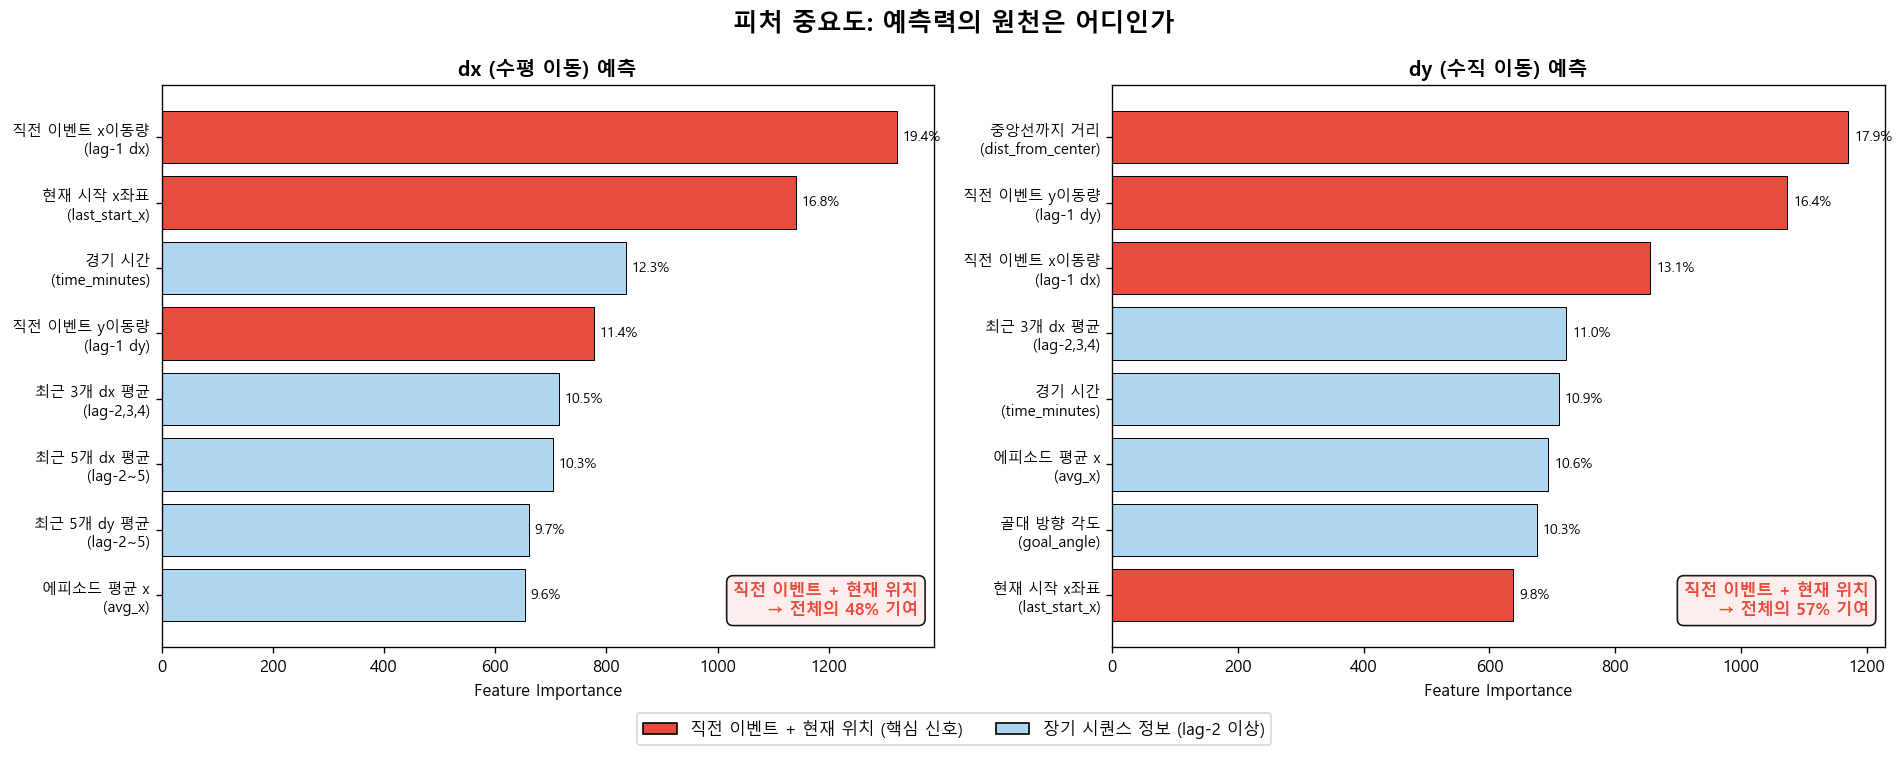

In [7]:
# 피처 중요도 (progress.md 분석 결과 기반)
features_dx = [
    ('직전 이벤트 x이동량\n(lag-1 dx)', 1323),
    ('현재 시작 x좌표\n(last_start_x)', 1141),
    ('경기 시간\n(time_minutes)', 836),
    ('직전 이벤트 y이동량\n(lag-1 dy)', 777),
    ('최근 3개 dx 평균\n(lag-2,3,4)', 714),
    ('최근 5개 dx 평균\n(lag-2~5)', 704),
    ('최근 5개 dy 평균\n(lag-2~5)', 661),
    ('에피소드 평균 x\n(avg_x)', 653),
]

features_dy = [
    ('중앙선까지 거리\n(dist_from_center)', 1170),
    ('직전 이벤트 y이동량\n(lag-1 dy)', 1074),
    ('직전 이벤트 x이동량\n(lag-1 dx)', 856),
    ('최근 3개 dx 평균\n(lag-2,3,4)', 722),
    ('경기 시간\n(time_minutes)', 710),
    ('에피소드 평균 x\n(avg_x)', 693),
    ('골대 방향 각도\n(goal_angle)', 675),
    ('현재 시작 x좌표\n(last_start_x)', 638),
]

# 직전 이벤트 + 현재 위치 vs 나머지 구분
def categorize(name):
    if 'lag-1' in name or '시작 x좌표' in name or '시작 y좌표' in name or '중앙선' in name:
        return '#E74C3C'  # 빨강: 핵심 신호 (직전+현재위치)
    return '#AED6F1'      # 파랑: 장기 시퀀스 정보

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('피처 중요도: 예측력의 원천은 어디인가', fontsize=15, fontweight='bold')

for ax, features, title, target in zip(
    axes,
    [features_dx, features_dy],
    ['dx (수평 이동) 예측', 'dy (수직 이동) 예측'],
    ['target_dx', 'target_dy']
):
    names = [f[0] for f in features]
    values = [f[1] for f in features]
    colors = [categorize(n) for n in names]
    total = sum(values)

    bars = ax.barh(range(len(names)), values, color=colors, edgecolor='black', linewidth=0.6)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')

    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                f'{val/total*100:.1f}%', va='center', fontsize=8.5)

    # 직전+현재위치가 차지하는 비율 계산
    core_sum = sum(v for n, v in features if categorize(n) == '#E74C3C')
    ax.text(0.98, 0.05,
            f'직전 이벤트 + 현재 위치\n→ 전체의 {core_sum/total*100:.0f}% 기여',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=10, fontweight='bold', color='#E74C3C',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FDEDEC', alpha=0.9))

# 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', edgecolor='black', label='직전 이벤트 + 현재 위치 (핵심 신호)'),
    Patch(facecolor='#AED6F1', edgecolor='black', label='장기 시퀀스 정보 (lag-2 이상)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 4. 에피소드 길이와 예측 오차의 관계
### 시퀀스가 길수록(= 더 많은 과거 정보가 있을수록) 예측이 더 좋아지는가?

In [8]:
# OOF 예측 결과 로드
oof = pd.read_csv('../oof_v11_classifier_regressor.csv')
df_merged = df.merge(oof[['game_episode', 'error_dist']], on='game_episode', how='inner')
print(f'병합 후: {len(df_merged)}')

FileNotFoundError: [Errno 2] No such file or directory: '../oof_v11_classifier_regressor.csv'

In [ ]:
# 에피소드 길이 구간별 평균 오차 계산
length_bins = [1, 3, 5, 7, 10, 15, 20, 100]
labels = ['1-2', '3-4', '5-6', '7-9', '10-14', '15-19', '20+']
df_merged['length_bin'] = pd.cut(df_merged['ep_length'], bins=length_bins, labels=labels)

grouped = df_merged.groupby('length_bin').agg(
    mean_error=('error_dist', 'mean'),
    median_error=('error_dist', 'median'),
    count=('error_dist', 'count')
).reset_index()

print(grouped.to_string())

In [ ]:
# ============================================================
# 핵심 시각화 2: 에피소드 길이 vs 예측 오차
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('에피소드 길이(과거 정보량)와 예측 오차의 관계', fontsize=15, fontweight='bold')

# 왼쪽: 에피소드 길이별 평균 오차 (막대)
ax1 = axes[0]
bars = ax1.bar(range(len(grouped)), grouped['mean_error'],
               color='#5DADE2', edgecolor='black', linewidth=0.7, alpha=0.85)
ax1.plot(range(len(grouped)), grouped['median_error'],
         'o--', color='#E74C3C', linewidth=2, markersize=7, label='중앙값 오차')
ax1.set_xticks(range(len(grouped)))
ax1.set_xticklabels(
    [f'{row["length_bin"]}\n(n={row["count"]:,})' for _, row in grouped.iterrows()],
    fontsize=9
)
ax1.set_xlabel('에피소드 길이 (이벤트 수)', fontsize=11)
ax1.set_ylabel('평균 유클리드 오차 (m)', fontsize=11)
ax1.set_title('에피소드 길이별 평균 예측 오차', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
for bar, val in zip(bars, grouped['mean_error']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}m', ha='center', va='bottom', fontsize=9)

# 오른쪽: 산점도 (길이 vs 오차)
ax2 = axes[1]
sc = ax2.scatter(df_merged['ep_length'], df_merged['error_dist'],
                 alpha=0.15, s=8, c='#2E86C1')

# 구간별 평균 선 추가
bin_centers = df_merged.groupby('length_bin').agg(
    mean_len=('ep_length', 'mean'),
    mean_err=('error_dist', 'mean')
).reset_index()
ax2.plot(bin_centers['mean_len'], bin_centers['mean_err'],
         'r-o', linewidth=2.5, markersize=8, label='구간 평균')

# 상관계수
corr = df_merged['ep_length'].corr(df_merged['error_dist'])
ax2.text(0.97, 0.95, f'상관계수: {corr:.3f}',
         transform=ax2.transAxes, ha='right', va='top',
         fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9))
ax2.set_xlabel('에피소드 길이 (이벤트 수)', fontsize=11)
ax2.set_ylabel('예측 오차 (m)', fontsize=11)
ax2.set_title('에피소드 길이 vs 예측 오차 분포', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 40)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('figures/episode_length_vs_error.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\n[해석]')
print(f'  에피소드 길이와 오차의 상관계수: {corr:.3f}')
print(f'  → 상관계수가 0에 가까울수록 과거 정보량이 예측에 영향을 미치지 않음')

## 5. 종합 요약

In [ ]:
print('=' * 65)
print('시퀀스 의존성 분석 요약')
print('=' * 65)

print('\n[1] Lag별 상관계수 감쇠')
for i, (dx, dy) in enumerate(zip(lag_corr_dx, lag_corr_dy)):
    print(f'  lag-{i+1}:  dx={abs(dx):.4f}  dy={abs(dy):.4f}')
decay = (1 - abs(lag_corr_dx[1]) / abs(lag_corr_dx[0])) * 100
print(f'  → lag-1에서 lag-2로 dx 상관계수 {decay:.1f}% 감쇠')

print('\n[2] 에피소드 길이 vs 오차')
print(f'  상관계수: {corr:.3f} (길이가 늘어도 오차 거의 불변)')

print('\n[결론]')
print('  이 데이터에는 장기 시퀀스 의존성이 없습니다.')
print('  예측에 필요한 핵심 정보는 직전 이벤트(lag-1)와 현재 위치에 집중됩니다.')
print('  시퀀스 모델이 갖는 장기 의존성 포착 능력이 이 문제에서 강점이 되지 못합니다.')